In [2]:
'''
Copied from the FastKAN library implementation of a KAN (https://github.com/ZiyaoLi/fast-kan)
with an additional option to set use_layernorm = False (for simplicity 
during verification).
'''

import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import *

class SplineLinear(nn.Linear):
    def __init__(self, in_features: int, out_features: int, init_scale: float = 0.1, **kw) -> None:
        self.init_scale = init_scale
        super().__init__(in_features, out_features, bias=False, **kw)

    def reset_parameters(self) -> None:
        nn.init.trunc_normal_(self.weight, mean=0, std=self.init_scale)

class RadialBasisFunction(nn.Module):
    def __init__(
        self,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        denominator: float = None,
    ):
        super().__init__()
        self.grid_min = grid_min
        self.grid_max = grid_max
        self.num_grids = num_grids
        grid = torch.linspace(grid_min, grid_max, num_grids)
        self.grid = torch.nn.Parameter(grid, requires_grad=False)
        self.denominator = denominator or (grid_max - grid_min) / (num_grids - 1)

    def forward(self, x):
        return torch.exp(-((x[..., None] - self.grid) / self.denominator) ** 2)

class FastKANLayer(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        use_base_update: bool = True,
        use_layernorm: bool = True,
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
    ) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.layernorm = None
        if use_layernorm:
            assert input_dim > 1, "Do not use layernorms on 1D inputs. Set `use_layernorm=False`."
            self.layernorm = nn.LayerNorm(input_dim)
        self.rbf = RadialBasisFunction(grid_min, grid_max, num_grids)
        self.spline_linear = SplineLinear(input_dim * num_grids, output_dim, spline_weight_init_scale)
        self.use_base_update = use_base_update
        if use_base_update:
            self.base_activation = base_activation
            self.base_linear = nn.Linear(input_dim, output_dim)

    def forward(self, x, use_layernorm=True):
        if self.layernorm is not None and use_layernorm:
            spline_basis = self.rbf(self.layernorm(x))
        else:
            spline_basis = self.rbf(x)
        ret = self.spline_linear(spline_basis.view(*spline_basis.shape[:-2], -1))
        if self.use_base_update:
            base = self.base_linear(self.base_activation(x))
            ret = ret + base
        return ret
    
    def get_all_curves(self, num_pts, num_extrapolate_bins):
        ng = self.rbf.num_grids # number of grid points in spline
        h = self.rbf.denominator # width of one single grid section 
        # For all points: generate x range by taking the minimum grid value and extending it slightly
        x = torch.linspace(
            self.rbf.grid_min - num_extrapolate_bins * h,
            self.rbf.grid_max + num_extrapolate_bins * h,
            num_pts,
            device=self.spline_linear.weight.device
        )
        # For all points: compute basis (ie. how close is each point to each grid point) and weights 
        basis = self.rbf(x) 
        w = self.spline_linear.weight.view(self.output_dim, self.input_dim, ng)
        # Einstein Summation for speed: multiply "basis activation" (how close x is to the grid) by the "weight" (how high the curve should be at that grid) and sums them up
        with torch.no_grad():
             y = torch.einsum('pg, oig -> oip', basis, w)
        return x.cpu().numpy(), y.cpu().numpy()

    def plot_curve(
        self,
        input_index: int,
        output_index: int,
        num_pts: int = 1000,
        num_extrapolate_bins: int = 2
    ):
        '''this function returns the learned curves in a FastKANLayer.
        input_index: the selected index of the input, in [0, input_dim) .
        output_index: the selected index of the output, in [0, output_dim) .
        num_pts: num of points sampled for the curve.
        num_extrapolate_bins (N_e): num of bins extrapolating from the given grids. The curve 
            will be calculate in the range of [grid_min - h * N_e, grid_max + h * N_e].
        '''
        ng = self.rbf.num_grids
        h = self.rbf.denominator
        assert input_index < self.input_dim
        assert output_index < self.output_dim
        w = self.spline_linear.weight[
            output_index, input_index * ng : (input_index + 1) * ng
        ]   # num_grids,
        x = torch.linspace(
            self.rbf.grid_min - num_extrapolate_bins * h,
            self.rbf.grid_max + num_extrapolate_bins * h,
            num_pts
        )   # num_pts, num_grids
        with torch.no_grad():
            y = (w * self.rbf(x.to(w.dtype))).sum(-1)
        return x, y


class FastKAN(nn.Module):
    def __init__(
        self,
        layers_hidden: List[int],
        grid_min: float = -2.,
        grid_max: float = 2.,
        num_grids: int = 8,
        use_base_update: bool = True,
        use_layernorm: bool = True,  # Added this parameter
        base_activation = F.silu,
        spline_weight_init_scale: float = 0.1,
    ) -> None:
        super().__init__()
        self.use_layernorm = use_layernorm 
        self.layers = nn.ModuleList([
            FastKANLayer(
                in_dim, out_dim,
                grid_min=grid_min,
                grid_max=grid_max,
                num_grids=num_grids,
                use_base_update=use_base_update,
                use_layernorm=use_layernorm,
                base_activation=base_activation,
                spline_weight_init_scale=spline_weight_init_scale,
            ) for in_dim, out_dim in zip(layers_hidden[:-1], layers_hidden[1:])
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x, use_layernorm=self.use_layernorm) 
        return x


class AttentionWithFastKANTransform(nn.Module):
    
    def __init__(
        self,
        q_dim: int,
        k_dim: int,
        v_dim: int,
        head_dim: int,
        num_heads: int,
        gating: bool = True,
        use_layernorm: bool = True,  # Added this parameter
    ):
        super(AttentionWithFastKANTransform, self).__init__()

        self.num_heads = num_heads
        total_dim = head_dim * self.num_heads
        self.gating = gating
        self.use_layernorm = use_layernorm
        self.linear_q = FastKANLayer(q_dim, total_dim, use_layernorm=use_layernorm)
        self.linear_k = FastKANLayer(k_dim, total_dim, use_layernorm=use_layernorm)
        self.linear_v = FastKANLayer(v_dim, total_dim, use_layernorm=use_layernorm)
        self.linear_o = FastKANLayer(total_dim, q_dim, use_layernorm=use_layernorm)
        self.linear_g = None
        if self.gating:
            self.linear_g = FastKANLayer(q_dim, total_dim, use_layernorm=use_layernorm)
        self.norm = head_dim**-0.5

    def forward(
        self,
        q: torch.Tensor,
        k: torch.Tensor,
        v: torch.Tensor,
        bias: torch.Tensor = None, 
    ) -> torch.Tensor:         

        wq = self.linear_q(q, use_layernorm=self.use_layernorm).view(*q.shape[:-1], 1, self.num_heads, -1) * self.norm     # *q1hc
        wk = self.linear_k(k, use_layernorm=self.use_layernorm).view(*k.shape[:-2], 1, k.shape[-2], self.num_heads, -1)    # *1khc
        att = (wq * wk).sum(-1).softmax(-2)     # *qkh
        del wq, wk
        if bias is not None:
            att = att + bias[..., None]

        wv = self.linear_v(v, use_layernorm=self.use_layernorm).view(*v.shape[:-2],1, v.shape[-2], self.num_heads, -1)     # *1khc
        o = (att[..., None] * wv).sum(-3)        # *qhc
        del att, wv

        o = o.view(*o.shape[:-2], -1)           # *q(hc)

        if self.linear_g is not None:
            # gating, use raw query input
            g = self.linear_g(q, use_layernorm=self.use_layernorm)
            o = torch.sigmoid(g) * o

        # merge heads
        o = self.linear_o(o, use_layernorm=self.use_layernorm)
        return o

In [3]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pulp import (
    GUROBI_CMD, LpBinary, LpMaximize, LpMinimize, LpProblem, 
    LpStatus, LpVariable, lpSum
)
import scipy as sc
from sklearn.metrics import r2_score
from src.custom_fastkan import FastKAN, FastKANLayer
import src.kan_verification_grapher as kan_verification_grapher
import ssl
import time
from torch import autograd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
from typing import List, Dict, Any, Tuple, Optional, Union
import gurobipy as gp
from gurobipy import GRB
import numpy as np
from joblib import Parallel, delayed

In [4]:
def train_mnist():
    ssl._create_default_https_context = ssl._create_unverified_context
    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
    )
    trainset = torchvision.datasets.MNIST(
        root="./data_mnist", train=True, download=True, transform=transform
    )
    valset = torchvision.datasets.MNIST(
        root="./data_mnist", train=False, download=True, transform=transform
    )
    trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
    valloader = DataLoader(valset, batch_size=64, shuffle=False)

    model = FastKAN([28 * 28, 8, 10], use_base_update=False, use_layernorm=False)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.8)

    criterion = nn.CrossEntropyLoss()
    for epoch in range(7):
        model.train()
        with tqdm(trainloader) as pbar:
            for i, (images, labels) in enumerate(pbar):
                images = images.view(-1, 28 * 28).to(device)
                optimizer.zero_grad()
                output = model(images)
                loss = criterion(output, labels.to(device))
                l2_reg = sum(torch.norm(param, p=2) for param in model.parameters())
                loss = loss + 0.01 * l2_reg
                loss.backward()
                optimizer.step()
                accuracy = (output.argmax(dim=1) == labels.to(device)).float().mean()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        model.eval()
        val_loss = 0
        val_accuracy = 0
        with torch.no_grad():
            for images, labels in valloader:
                images = images.view(-1, 28 * 28).to(device)
                output = model(images)
                val_loss += criterion(output, labels.to(device)).item()
                val_accuracy += (
                    (output.argmax(dim=1) == labels.to(device)).float().mean().item()
                )
        val_loss /= len(valloader)
        val_accuracy /= len(valloader)
        scheduler.step()

        print(
            f"Epoch {epoch + 1}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}"
        )
    return model

my_kan = train_mnist()

100%|██████████| 938/938 [00:04<00:00, 213.65it/s, accuracy=0.562, loss=1.71, lr=0.001]


Epoch 1, Val Loss: 1.1924177058942758, Val Accuracy: 0.6768511146496815


100%|██████████| 938/938 [00:04<00:00, 212.92it/s, accuracy=0.719, loss=1.05, lr=0.0008] 


Epoch 2, Val Loss: 0.774576389106216, Val Accuracy: 0.78234474522293


100%|██████████| 938/938 [00:04<00:00, 210.95it/s, accuracy=0.844, loss=0.78, lr=0.00064] 


...

Epoch 5, Val Loss: 0.39966499430548613, Val Accuracy: 0.8923168789808917


100%|██████████| 938/938 [00:03<00:00, 234.51it/s, accuracy=0.844, loss=0.853, lr=0.000328]


Epoch 6, Val Loss: 0.3989059290593597, Val Accuracy: 0.8915207006369427


100%|██████████| 938/938 [00:04<00:00, 234.15it/s, accuracy=0.875, loss=0.94, lr=0.000262] 


Epoch 7, Val Loss: 0.3487707082727912, Val Accuracy: 0.904359076433121


100%|██████████| 6352/6352 [00:16<00:00, 388.82it/s]


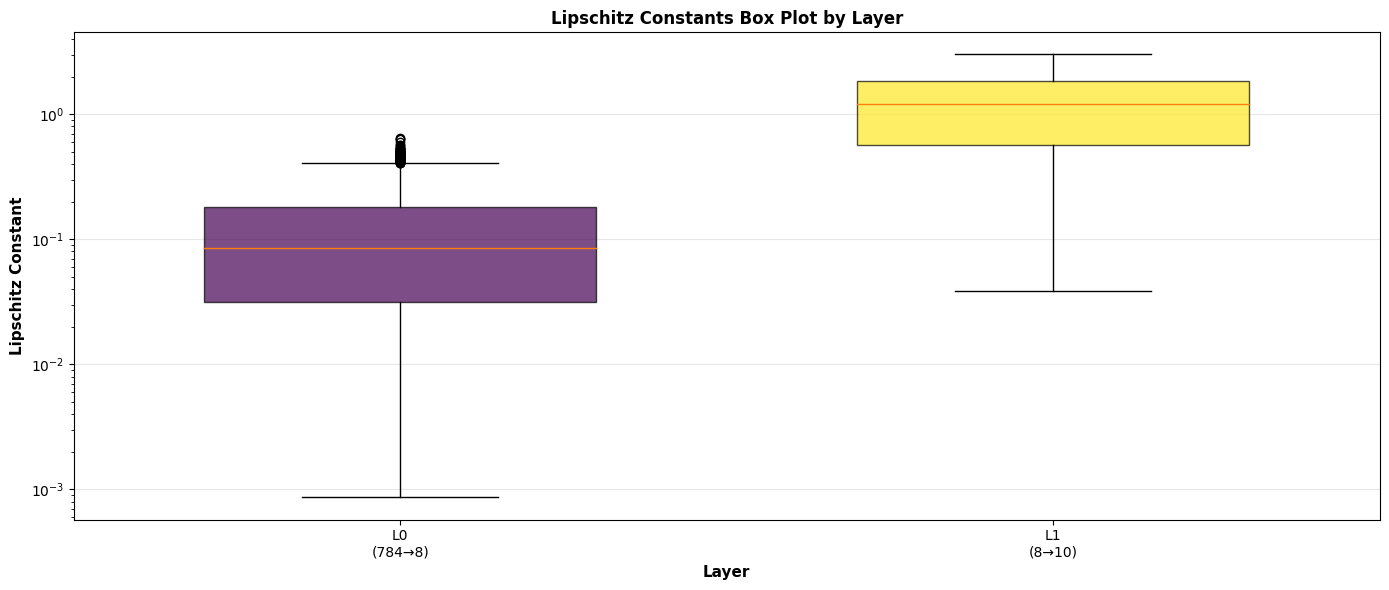

In [5]:
def fit_line_through_points(x1, y1, x2, y2):
    slope = (y2 - y1) / (x2 - x1)
    intercept = y1 - slope * x1
    return slope, intercept

def find_bspline_segments_from_data(x_points, y_points, max_segments):
    n_samples = len(x_points)
    
    # 1. Precompute errors for all possible segments (ONCE)
    errors = np.full((n_samples, n_samples), np.inf)
    for start_idx in range(n_samples-1):
        x_start = x_points[start_idx]
        y_start = y_points[start_idx]
        for end_idx in range(start_idx + 1, n_samples):
            x_end = x_points[end_idx]
            y_end = y_points[end_idx]
            slope, intercept = fit_line_through_points(x_start, y_start, x_end, y_end)
            segment_x = x_points[start_idx:end_idx+1]
            segment_y = y_points[start_idx:end_idx+1]
            predicted_y = slope * segment_x + intercept
            segment_error = np.max(np.abs(predicted_y - segment_y))
            errors[start_idx, end_idx] = segment_error
    
    # 2. Dynamic programming to find optimal segmentation (ONCE)
    dp_table = np.full((max_segments, n_samples), np.inf)
    backtrack = np.zeros((max_segments, n_samples), dtype=int)
    
    # Base Case: 1 segment
    for j in range(1, n_samples):
        dp_table[0, j] = errors[0, j]
    
    # Recurrence
    for i in range(1, max_segments):
        for j in range(i+1, n_samples):
            # We try breaking at k, where k is between the start of this segment number and current point
            # k is the END of the previous segment
            for k in range(i, j): 
                if dp_table[i-1, k] == np.inf: continue
                if errors[k, j] == np.inf: continue
                
                curr_error = max(dp_table[i-1, k], errors[k, j])
                if curr_error < dp_table[i, j]:
                    dp_table[i, j] = curr_error
                    backtrack[i, j] = k

    # Extract results for EVERY segment count from 1 to max_segments
    results = {}
    for seg_count in range(1, max_segments + 1):
        row_idx = seg_count - 1
        final_error = dp_table[row_idx, n_samples-1]
        if final_error == np.inf:
            results[seg_count] = ([], np.inf)
            continue

        # Reconstruct segments for this specific count using the backtrack table
        segments = []
        curr_seg_end = n_samples - 1
        
        for i in range(row_idx, -1, -1):
            if i > 0:
                prev_seg_end = backtrack[i, curr_seg_end]
            else:
                prev_seg_end = 0
            
            x1, y1 = x_points[prev_seg_end], y_points[prev_seg_end]
            x2, y2 = x_points[curr_seg_end], y_points[curr_seg_end]
            slope, intercept = fit_line_through_points(x1, y1, x2, y2)
            segments.insert(0, (x1, x2, slope, intercept))
            
            curr_seg_end = prev_seg_end
        
        results[seg_count] = (segments, final_error)
        
    return results

def calculate_lipschitz_from_data(x_np, y_np, grid_min, grid_max):
    mask = (x_np >= grid_min) & (x_np <= grid_max)
    x_masked = x_np[mask]
    y_masked = y_np[mask]

    dx = np.diff(x_masked)
    dy = np.diff(y_masked)
    nonzero_dx = dx != 0
    slopes = np.zeros_like(dx)
    slopes[nonzero_dx] = dy[nonzero_dx] / dx[nonzero_dx]
    if len(slopes) == 0: return 0.0
    lipschitz_constant = np.max(np.abs(slopes))
    return lipschitz_constant

def validate_segments_error(segments, x_high, y_high):
    max_error = 0.0
    for (sx1, sx2, slope, intercept) in segments:
        mask = (x_high >= sx1) & (x_high <= sx2)
        if not np.any(mask):
            continue
        y_real = y_high[mask]
        y_pred = slope * x_high[mask] + intercept
        current_max = np.max(np.abs(y_real - y_pred))
        if current_max > max_error:
            max_error = current_max
            
    return max_error

def process_single_spline(layer_idx, input_idx, output_idx, x_dp, y_dp, x_high, y_high, max_segments, grid_min, grid_max):
    results_low_res = find_bspline_segments_from_data(x_dp, y_dp, max_segments)
    results_validated = {}
    for k, (segs, low_res_err) in results_low_res.items():
        if low_res_err == np.inf or len(segs) == 0:
             results_validated[k] = ([], np.inf)
             continue
             
        true_error = validate_segments_error(segs, x_high, y_high)
        results_validated[k] = (segs, true_error)
        
    lip = calculate_lipschitz_from_data(x_high, y_high, grid_min, grid_max)
    return (layer_idx, input_idx, output_idx), results_validated, lip

def compute_dp_tables_lipschitz(kan_model, max_segments):
    tasks = []
    for layer_idx, layer in enumerate(kan_model.layers):
        input_dim = layer.input_dim
        output_dim = layer.output_dim
        all_x_high, all_y_high = layer.get_all_curves(num_pts=1000, num_extrapolate_bins=2)

        for input_idx in range(input_dim):
            for output_idx in range(output_dim):
                # Create Low-Res Subsample (25 pts) for DP
                indices = np.linspace(0, 999, max_segments, dtype=int)
                x_dp = all_x_high[indices]
                y_dp = all_y_high[output_idx, input_idx, indices]
                # Full Res for Validation/Lipschitz
                x_high = all_x_high
                y_high = all_y_high[output_idx, input_idx, :]

                tasks.append((
                    layer_idx, input_idx, output_idx, 
                    x_dp, y_dp,       # Pass low res
                    x_high, y_high,   # Pass high res
                    max_segments, 
                    layer.rbf.grid_min, layer.rbf.grid_max
                ))
    results_list = Parallel(n_jobs=-1)(
        delayed(process_single_spline)(
            l_idx, i_idx, o_idx, x_dp, y_dp, x_high, y_high, max_seg, g_min, g_max
        ) 
        for l_idx, i_idx, o_idx, x_dp, y_dp, x_high, y_high, max_seg, g_min, g_max in tqdm(tasks)
    )
    error_tables = {}
    segments_tables = {}
    lipschitz_constants = {}

    for key, all_results, lip_const in results_list:
        error_table = {}
        segments_table = {}
        for k, (segs, err) in all_results.items():
            segments_table[k] = segs
            error_table[k] = err
        
        error_tables[key] = error_table
        segments_tables[key] = segments_table
        lipschitz_constants[key] = lip_const

    return error_tables, segments_tables, lipschitz_constants

def plot_lipschitz_comparison_by_layer(lipschitz_constants, kan_model, figsize=(14, 6)):
    num_layers = len(kan_model.layers)
    layer_data = {i: [] for i in range(num_layers)}
    
    for (layer_idx, input_idx, output_idx), lip_const in lipschitz_constants.items():
        if np.isfinite(lip_const):
            layer_data[layer_idx].append(lip_const)
    fig, ax2 = plt.subplots(1, 1, figsize=figsize)
    positions = []
    data_to_plot = []
    labels = []
    for layer_idx in range(num_layers):
        if layer_data[layer_idx]:
            positions.append(layer_idx)
            data_to_plot.append(layer_data[layer_idx])
            layer = kan_model.layers[layer_idx]
            labels.append(f'L{layer_idx}\n({layer.input_dim}→{layer.output_dim})')
    bp = ax2.boxplot(data_to_plot, positions=positions, patch_artist=True,
                     labels=labels, widths=0.6)
    colors = plt.cm.viridis(np.linspace(0, 1, len(data_to_plot)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_xlabel('Layer', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Lipschitz Constant', fontsize=11, fontweight='bold')
    ax2.set_title('Lipschitz Constants Box Plot by Layer', fontsize=12, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    return fig

error_tables, segments_tables, lipschitz_constants = compute_dp_tables_lipschitz(my_kan, 40)
fig2 = plot_lipschitz_comparison_by_layer(lipschitz_constants, my_kan)
plt.show()

In [6]:
def weight_dp_tables_lipschitz(kan_model, error_tables, segments_tables, lipschitz_constants):
    node_sensitivities = {}
    num_layers = len(kan_model.layers)
    
    # Intialize final layer with all 1's
    final_layer = kan_model.layers[num_layers - 1]
    for out_idx in range(final_layer.output_dim):
        node_sensitivities[(num_layers, out_idx)] = 1.0

    # Calculate sensitivity for the inputs of a layer based on the output layer's sensitivities
    layer_idx = num_layers - 1
    while layer_idx >= 0:
        current_layer = kan_model.layers[layer_idx]
        for input_idx in range(current_layer.input_dim):
            sensitivity_sum = 0.0
            for output_idx in range(current_layer.output_dim):
                lipschitz_constant = lipschitz_constants.get((layer_idx, input_idx, output_idx), 0.0)
                child_node_sensitivity = node_sensitivities[(layer_idx + 1, output_idx)]
                sensitivity_sum += lipschitz_constant * child_node_sensitivity
            node_sensitivities[(layer_idx, input_idx)] = sensitivity_sum
        layer_idx -= 1

    # Weight the error table (just do sensitivities * table)
    weighted_error_tables = {}
    for layer_idx, layer in enumerate(kan_model.layers):
        for input_idx in range(layer.input_dim):
            for output_idx in range(layer.output_dim):
                current_bspline_key = (layer_idx, input_idx, output_idx)
                # The error of a spline is added directly to its destination node (output_idx)
                sensitivity_of_current_output_node = node_sensitivities[(layer_idx + 1, output_idx)]
                weighted_table_for_bspline = {}
                for pair in error_tables[current_bspline_key].items():
                    num_segments = pair[0]
                    error = pair[1]
                    weighted_table_for_bspline[num_segments] = error * sensitivity_of_current_output_node
                weighted_error_tables[current_bspline_key] = weighted_table_for_bspline
    return weighted_error_tables

def plot_error_comparison_by_layer(error_tables, weighted_error_tables, kan_model, max_segments=15, figsize=(14, 8)):
    num_layers = len(kan_model.layers)
    sample_splines = []
    layer_idx = num_layers 
    for layer_idx in range(num_layers):
        layer = kan_model.layers[layer_idx]
        # Pick ALL splines in this layer
        for input_idx in range(layer.input_dim):
            for output_idx in range(layer.output_dim):
                spline_key = (layer_idx, input_idx, output_idx)
                if spline_key in error_tables and spline_key in weighted_error_tables:
                    sample_splines.append(spline_key)
                else:
                    print(f"Warning: Spline {spline_key} not found in tables")
    if not sample_splines:
        print("No valid splines found to plot")
        return None
    num_splines = len(sample_splines)
    cols = min(4, num_splines)
    rows = (num_splines + cols - 1) // cols
    if figsize is None:
        figsize = (5 * cols, 4 * rows)
    fig, axes = plt.subplots(rows, cols, figsize=(20, 16), squeeze=False)
    axes = axes.flatten()
    for idx, spline_key in enumerate(sample_splines):
        layer_idx, input_idx, output_idx = spline_key
        layer = kan_model.layers[layer_idx]
        original_errors = error_tables[spline_key]
        weighted_errors = weighted_error_tables[spline_key]
        num_segments_list = sorted([k for k in original_errors.keys() if k <= max_segments])
        original_vals = [original_errors[k] for k in num_segments_list if np.isfinite(original_errors[k])]
        weighted_vals = [weighted_errors[k] for k in num_segments_list if np.isfinite(weighted_errors[k])]
        min_len = min(len(num_segments_list), len(original_vals), len(weighted_vals))
        num_segments_list = num_segments_list[:min_len]
        original_vals = original_vals[:min_len]
        weighted_vals = weighted_vals[:min_len]
        ax = axes[idx]
        ax.plot(num_segments_list, original_vals, 'o-', label='Original Error', 
                color='steelblue', linewidth=2, markersize=6)
        ax.plot(num_segments_list, weighted_vals, 's-', label='Weighted Error', 
                color='coral', linewidth=2, markersize=6)
        ax.set_xlabel('Number of Segments', fontsize=10, fontweight='bold')
        ax.set_ylabel('Max Error', fontsize=10, fontweight='bold')
        ax.set_title(f'Layer {layer_idx} ({layer.input_dim}→{layer.output_dim})\n'
                    f'Spline ({input_idx}→{output_idx})', 
                    fontsize=11, fontweight='bold')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
        if original_vals and weighted_vals and original_vals[-1] > 0:
            ratio = weighted_vals[-1] / original_vals[-1]
            ax.text(0.05, 0.95, f'Weight Ratio: {ratio:.2f}x', 
                   transform=ax.transAxes, fontsize=9,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.tight_layout()
    fig.suptitle('Original vs Weighted Error by Layer', fontsize=13, fontweight='bold', y=1.02)
    return fig

weighted_error_tables = weight_dp_tables_lipschitz(my_kan, error_tables, segments_tables, lipschitz_constants)
# fig = plot_error_comparison_by_layer(error_tables, weighted_error_tables, my_kan, max_segments=30)
# plt.show()

In [7]:
def solve_best_segment_allocation(weighted_error_tables, target_max_error):
    model = gp.Model()
    model.setParam("OutputFlag", 0)
    # Create binary variable x[spline_key, num_segments] for every choice and every spline
    x = {}
    binary_vars_for_splines = {} 
    for spline_key, num_segment_options in weighted_error_tables.items():
        binary_vars_for_splines[spline_key] = []
        for pair in num_segment_options.items():
            k_segments = pair[0]
            error_val = pair[1]
            if np.isinf(error_val):
                continue
            x[(spline_key, k_segments)] = model.addVar(vtype=GRB.BINARY, obj=k_segments)
            binary_vars_for_splines[spline_key].append(x[(spline_key, k_segments)])
    model.update()

    # Make sure we can only pick 1 variable
    for pair in binary_vars_for_splines.items():
        spline_key = pair[0]
        variables = pair[1]
        model.addConstr(gp.quicksum(variables) == 1)
    # Make sure we're under the max error
    total_error_expr = gp.quicksum(weighted_error_tables[s_key][k] * x[(s_key, k)] for s_key, k in x.keys())
    model.addConstr(total_error_expr <= target_max_error)

    # Minimize the total number of segments
    total_segments_expr = gp.quicksum(
        k * x[(s_key, k)] 
        for s_key, k in x.keys()
    )
    model.setObjective(total_segments_expr, GRB.MINIMIZE)

    # Optimize!
    model.optimize()
    optimal_allocation = {}
    if model.status == GRB.OPTIMAL:
        print(f"Optimization successful! Minimum Segments Required: {model.objVal}")
        for (spline_key, k_segments), variable in x.items():
            if variable.X > 0.5:
                optimal_allocation[spline_key] = k_segments
        return optimal_allocation, model.objVal
    elif model.status == GRB.INFEASIBLE:
        print("Model is INFEASIBLE. It is impossible to achieve this low of an error with the available segment options.")
        return None, float('inf')
    else:
        print(f"Optimization ended with status code: {model.status}")
        return None, float('inf')

optimal_allocation, min_error = solve_best_segment_allocation(weighted_error_tables, 300.0)

Set parameter Username
Set parameter LicenseID to value 2620375
Academic license - for non-commercial use only - expires 2026-02-10
Optimization successful! Minimum Segments Required: 49888.0


In [ ]:
from joblib import Parallel, delayed

def get_spline_bounds(segments, x_min, x_max):
    y_min, y_max = np.inf, -np.inf
    for (sx1, sx2, slope, intercept) in segments:
        # Find the intersection of the segment domain and input domain
        overlap_start = max(sx1, x_min)
        overlap_end = min(sx2, x_max)
        # If they overlap, evaluate the line at the edges
        if overlap_start <= overlap_end:
            val_start = slope * overlap_start + intercept
            val_end = slope * overlap_end + intercept
            y_min = min(y_min, val_start, val_end)
            y_max = max(y_max, val_start, val_end)
    return y_min, y_max


def propagate_kan_intervals(kan_shape, segments_tables, error_tables, optimal_allocation, input_lb, input_ub):
    layer_bounds = []
    # Input layer
    current_lb = input_lb
    current_ub = input_ub
    layer_bounds.append((current_lb, current_ub))
    num_transitions = len(kan_shape) - 1

    # Propagate across all layers 
    for layer_idx in range(num_transitions):
        in_dim = kan_shape[layer_idx]
        out_dim = kan_shape[layer_idx + 1]
        next_lb = np.zeros(out_dim)
        next_ub = np.zeros(out_dim)
        for dst in range(out_dim):
            # Min_sum = Sum(Min_parts), Max_sum = Sum(Max_parts)
            total_min = 0.0
            total_max = 0.0
            for src in range(in_dim):
                x_min = current_lb[src]
                x_max = current_ub[src]
                num_segs = optimal_allocation[(layer_idx, src, dst)]
                segs = segments_tables[(layer_idx, src, dst)][num_segs]

                approx_error = error_tables[(layer_idx, src, dst)][num_segs]

                s_min, s_max = get_spline_bounds(segs, x_min, x_max)
                total_min += s_min - approx_error
                total_max += s_max + approx_error
            next_lb[dst] = total_min
            next_ub[dst] = total_max
        layer_bounds.append((next_lb, next_ub))
        current_lb, current_ub = next_lb, next_ub
    return layer_bounds

def build_kan_milp_model(kan_shape, segments_tables, error_tables, optimal_allocation, x_min_vec, x_max_vec):
    model = gp.Model()
    input_dim = kan_shape[0] 
    all_layer_variables = []

    # Create Input Variables
    current_layer_range_variables = []
    for i in range(input_dim):
        input_range_variable = model.addVar(lb=x_min_vec[i], ub=x_max_vec[i])
        current_layer_range_variables.append(input_range_variable)
    all_layer_variables.append(current_layer_range_variables)

    # Build Hidden Layers Sequentially
    num_transitions = len(kan_shape) - 1 # If shape is [784, 32, 10], we have 2 transitions: 0->1 and 1->2
    for layer_idx in range(num_transitions):
        layer_input_dimension = kan_shape[layer_idx]
        layer_output_dimension = kan_shape[layer_idx + 1]
        
        # Initialize output variables for this layer (by creating our list of inputs to the next layer)
        next_layer_input_ranges = []
        for i in range(layer_output_dimension): 
            next_layer_input_ranges.append(gp.LinExpr()) # ex. layer2_neuron_i = layer1_neuron1 + layer1_neuron2 + ... (linear expression!)
        
        for src_idx in range(layer_input_dimension):
            for dst_idx in range(layer_output_dimension):
                # Extract PWL Points
                num_segs = optimal_allocation[(layer_idx, src_idx, dst_idx)]
                seg_data = segments_tables[(layer_idx, src_idx, dst_idx)][num_segs] # table has all possible segment allocations, only extract the optimal one (num_segs)
                x_pts, y_pts = [], []
                for idx, (x1, x2, slope, intercept) in enumerate(seg_data):
                    x_pts.append(x1)
                    y_pts.append(slope * x1 + intercept)
                    if idx == len(seg_data) - 1: # Add end point of last segment
                        x_pts.append(x2)
                        y_pts.append(slope * x2 + intercept)

                # Create output variable for each bspline (adding in error)
                approx_error = error_tables[(layer_idx, src_idx, dst_idx)][num_segs]
                error_var = model.addVar(lb=-approx_error, ub=approx_error)
                src_var = current_layer_range_variables[src_idx]
                result_var = model.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY)
                model.addGenConstrPWL(src_var, result_var, x_pts, y_pts) # "The relationship between src_var and result_var must follow the path connected by the dots"
                next_layer_input_ranges[dst_idx] += result_var + error_var # fill in the output linear expressions we defined earlier (for each neuron in the next layer)

        # Create variables for next layer nodes
        next_layer_range_variables = []
        for j in range(layer_output_dimension):
            next_layer_range_variable = model.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY)
            model.addConstr(next_layer_range_variable == next_layer_input_ranges[j])
            next_layer_range_variables.append(next_layer_range_variable)
        current_layer_range_variables = next_layer_range_variables
        
        all_layer_variables.append(current_layer_range_variables)

    model.update()
    return model, all_layer_variables

def solve_kan_interval_milp(kan_shape, segments_tables, error_tables, optimal_allocation, output_layer_mip_gap, x_min_vec, x_max_vec):
    precomputed_bounds = propagate_kan_intervals(
        kan_shape, 
        segments_tables, 
        error_tables,
        optimal_allocation, 
        x_min_vec, 
        x_max_vec
    )
    model, all_layer_variables = build_kan_milp_model(
        kan_shape, 
        segments_tables, 
        error_tables,
        optimal_allocation, 
        x_min_vec, 
        x_max_vec
    )
    model.setParam("PreSolve", 2)
    # Apply the precomputed bounds
    for layer_idx, vars_in_layer in enumerate(all_layer_variables):
        lbs, ubs = precomputed_bounds[layer_idx]
        for neuron_idx, var in enumerate(vars_in_layer):
            var.lb = lbs[neuron_idx]
            var.ub = ubs[neuron_idx] 
    model.update()

    # Solve only the final layer
    final_layer_vars = all_layer_variables[-1]
    # extract the variable id's so we can make len(final_layer_vars) different models
    target_indices = [v.index for v in final_layer_vars]
    
    def solve_single_neuron(var_index):
        # Create a copy of the model, restrict to 1 thread, copy over variables using index
        local_model = model.copy()
        local_model.setParam("MIPGap", output_layer_mip_gap)
        local_model.setParam("Threads", 1) 
        target_var = local_model.getVars()[var_index]
        # Minimize
        local_model.setObjective(target_var, GRB.MINIMIZE)
        local_model.optimize()
        min_val = local_model.ObjBound
        # Maximize
        local_model.setObjective(target_var, GRB.MAXIMIZE)
        local_model.optimize()
        max_val = local_model.ObjBound
        return min_val, max_val

    results = Parallel(n_jobs=-1, backend="threading")(delayed(solve_single_neuron)(idx) for idx in target_indices)
    min_bounds = np.array([r[0] for r in results])
    max_bounds = np.array([r[1] for r in results])
    return min_bounds, max_bounds

kan_shape = [my_kan.layers[0].input_dim]
for layer in my_kan.layers:
    kan_shape.append(layer.output_dim)
x_min_vec = np.full(kan_shape[0], -0.5)
x_max_vec = np.full(kan_shape[0], 0.5)

output_layer_mip_gap = 0.05
min_outputs, max_outputs = solve_kan_interval_milp(
    kan_shape,
    segments_tables, 
    error_tables,
    optimal_allocation, 
    output_layer_mip_gap,
    x_min_vec, 
    x_max_vec
)

print("Minimum Output Bounds:", min_outputs)
print("Maximum Output Bounds:", max_outputs)
#3.7 vs 3.5
#9.4 vs 11.0
# 1m 45s vs 51.2s

Set parameter Presolve to value 2
Set parameter MIPGap to value 0.05
Set parameter MIPGap to value 0.05
Set parameter MIPGap to value 0.05
Set parameter MIPGap to value 0.05
Set parameter MIPGap to value 0.05
Set parameter MIPGap to value 0.05
Set parameter MIPGap to value 0.05
Set parameter MIPGap to value 0.05
Set parameter MIPGap to value 0.05
Set parameter MIPGap to value 0.05
Set parameter Threads to value 1
Set parameter Threads to value 1
Set parameter Threads to value 1
Set parameter Threads to value 1
Set parameter Threads to value 1
Set parameter Threads to value 1
Set parameter Threads to value 1
Set parameter Threads to value 1
Set parameter Threads to value 1
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G419)
Set parameter Threads to value 1
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G419)
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G419)
Gurobi Optimizer version 12.0.1

KeyboardInterrupt: 

  2572  2108    5.60703  390   85   -9.35902    5.60703   160%  66.2   65s
  3041  2364    5.98789  267 1373   -9.16894    6.13260   167%  31.1   70s
  4333  3393   -9.56763  915   89          -   -9.56772      -  68.4  160s
  4671  3681   -9.22527 1068   85          -   -9.22527      -  37.9  160s
  3864  2568   -7.46106  131  934   -6.47287   -7.56834  16.9%  92.5  160s
  3525  2872   -6.41194  497  728          -   -6.47628      -  98.3  160s
  3444  2882   -9.49845  463  699          -   -9.74432      -  82.5  160s
H 3866  2327                      -6.6297015   -7.56834  14.2%  92.4  161s
* 4523  3369            1011      -9.4688865   -9.56772  1.04%  66.1  163s

Cutting planes:
  Gomory: 62
  Cover: 78
  Implied bound: 38
  Clique: 4
  MIR: 59
  Flow cover: 110
  Relax-and-lift: 40

Explored 4524 nodes (314419 simplex iterations) in 163.12 seconds (162.64 work units)
Thread count was 1 (of 10 available processors)

Solution count 1: -9.46889 

Optimal solution found (tolerance 5.0

# Sensitivity Analysis

In [ ]:
def add_kan_structure_to_model(model, prefix, kan_shape, segments_tables, error_tables, optimal_allocation, x_min_vec, x_max_vec, precomputed_bounds):
    """
    Adds KAN variables and constraints to an EXISTING model.
    Returns: input_vars, output_vars
    """
    input_dim = kan_shape[0] 
    all_layer_variables = []

    # 1. Create Input Variables
    current_layer_range_variables = []
    for i in range(input_dim):
        # We use the global bounds for the input
        var_name = f"{prefix}_L0_N{i}"
        input_range_variable = model.addVar(lb=x_min_vec[i], ub=x_max_vec[i], name=var_name)
        current_layer_range_variables.append(input_range_variable)
    all_layer_variables.append(current_layer_range_variables)

    # 2. Build Hidden Layers
    num_transitions = len(kan_shape) - 1
    for layer_idx in range(num_transitions):
        layer_input_dimension = kan_shape[layer_idx]
        layer_output_dimension = kan_shape[layer_idx + 1]
        
        # Initialize linear accumulators for next layer
        next_layer_input_ranges = []
        for i in range(layer_output_dimension): 
            next_layer_input_ranges.append(gp.LinExpr()) 
        
        for src_idx in range(layer_input_dimension):
            for dst_idx in range(layer_output_dimension):
                # Extract PWL Points
                num_segs = optimal_allocation[(layer_idx, src_idx, dst_idx)]
                seg_data = segments_tables[(layer_idx, src_idx, dst_idx)][num_segs]
                x_pts, y_pts = [], []
                for idx, (x1, x2, slope, intercept) in enumerate(seg_data):
                    x_pts.append(x1)
                    y_pts.append(slope * x1 + intercept)
                    if idx == len(seg_data) - 1: 
                        x_pts.append(x2)
                        y_pts.append(slope * x2 + intercept)

                # Variables
                approx_error = error_tables[(layer_idx, src_idx, dst_idx)][num_segs]
                
                # Error variable (slack)
                err_name = f"{prefix}_L{layer_idx}_S{src_idx}_{dst_idx}_err"
                error_var = model.addVar(lb=-approx_error, ub=approx_error, name=err_name)
                
                # Source variable (from previous layer)
                src_var = current_layer_range_variables[src_idx]
                
                # Spline Output Variable
                # We need bounds for the PWL constraints to work efficiently
                res_name = f"{prefix}_L{layer_idx}_S{src_idx}_{dst_idx}_out"
                result_var = model.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY, name=res_name)
                
                model.addGenConstrPWL(src_var, result_var, x_pts, y_pts)
                
                # Add to accumulator
                next_layer_input_ranges[dst_idx] += result_var + error_var 

        # Create variables for next layer nodes (Summation)
        next_layer_range_variables = []
        # Get precomputed bounds for this specific layer index (layer_idx + 1 because layer 0 is inputs)
        # precomputed_bounds[0] is input, precomputed_bounds[1] is Layer 1 output
        layer_lbs, layer_ubs = precomputed_bounds[layer_idx + 1]

        for j in range(layer_output_dimension):
            node_name = f"{prefix}_L{layer_idx+1}_N{j}"
            # Apply tight bounds from propagation
            next_layer_range_variable = model.addVar(lb=layer_lbs[j], ub=layer_ubs[j], name=node_name)
            model.addConstr(next_layer_range_variable == next_layer_input_ranges[j])
            next_layer_range_variables.append(next_layer_range_variable)
            
        current_layer_range_variables = next_layer_range_variables
        all_layer_variables.append(current_layer_range_variables)

    model.update()
    # Return Input vars (Layer 0) and Output vars (Last Layer)
    return all_layer_variables[0], all_layer_variables[-1]

def solve_sensitivity_analysis(kan_shape, segments_tables, error_tables, optimal_allocation, 
                               x_min_vec, x_max_vec, perturbation_epsilon, 
                               mip_gap=0.05, timeout=60):
    
    print(f"Building Sensitivity Model (Perturbation Epsilon: {perturbation_epsilon})...")
    
    # 1. Precompute bounds (We use the same bounds for both Copy A and Copy B)
    precomputed_bounds = propagate_kan_intervals(
        kan_shape, segments_tables, error_tables, optimal_allocation, x_min_vec, x_max_vec
    )

    # 2. Initialize Model
    model = gp.Model()
    model.setParam("OutputFlag", 0)
    model.setParam("PreSolve", 2)
    
    # 3. Build Two Copies of the KAN
    # Network A
    in_vars_A, out_vars_A = add_kan_structure_to_model(
        model, "A", kan_shape, segments_tables, error_tables, optimal_allocation, 
        x_min_vec, x_max_vec, precomputed_bounds
    )
    # Network B
    in_vars_B, out_vars_B = add_kan_structure_to_model(
        model, "B", kan_shape, segments_tables, error_tables, optimal_allocation, 
        x_min_vec, x_max_vec, precomputed_bounds
    )
    
    # 4. Add Perturbation Constraints
    # |Input_A - Input_B| <= epsilon
    # We assume Input A and Input B can be anywhere in the valid domain (x_min_vec, x_max_vec),
    # but they must be close to each other.
    input_dim = len(in_vars_A)
    for i in range(input_dim):
        # A - B <= eps  =>  A - B - eps <= 0
        model.addConstr(in_vars_A[i] - in_vars_B[i] <= perturbation_epsilon)
        # B - A <= eps  =>  B - A - eps <= 0
        model.addConstr(in_vars_B[i] - in_vars_A[i] <= perturbation_epsilon)

    model.update()
    
    output_dim = len(out_vars_A)
    
    # 5. Parallel Solve for Sensitivity (Max Divergence)
    def solve_divergence(out_idx):
        local_model = model.copy()
        local_model.setParam("Threads", 1)
        local_model.setParam("MIPGap", mip_gap)
        local_model.setParam("TimeLimit", timeout)
        
        # Retrieve variables in local copy
        # We need to find the variables by name because Gurobi objects aren't thread-transferable
        var_A = local_model.getVarByName(f"A_L{len(kan_shape)-1}_N{out_idx}")
        var_B = local_model.getVarByName(f"B_L{len(kan_shape)-1}_N{out_idx}")
        
        # Objective: (OutputA - OutputB)
        diff = var_A - var_B
        
        # Find Maximum Divergence (Most Positive Difference)
        local_model.setObjective(diff, GRB.MAXIMIZE)
        local_model.optimize()
        max_diff = local_model.ObjBound if local_model.status != GRB.INF_OR_UNBD else float('inf')
        
        # Find Minimum Divergence (Most Negative Difference)
        local_model.setObjective(diff, GRB.MINIMIZE)
        local_model.optimize()
        min_diff = local_model.ObjBound if local_model.status != GRB.INF_OR_UNBD else float('-inf')
        
        # The "Sensitivity" is the maximum absolute change possible given the epsilon
        sensitivity = max(abs(max_diff), abs(min_diff))
        return out_idx, min_diff, max_diff, sensitivity

    print("Optimizing divergence...")
    results = Parallel(n_jobs=-1, backend="threading")(
        delayed(solve_divergence)(i) for i in range(output_dim)
    )
    
    # Formatting results
    results.sort(key=lambda x: x[0])
    return results

# --- Run Sensitivity Analysis ---

# Define domain
epsilon_domain = 0.5
x_min_vec = np.full(kan_shape[0], -epsilon_domain)
x_max_vec = np.full(kan_shape[0], epsilon_domain)

# Define Perturbation size (e.g., L_inf norm of 0.01)
perturbation_size = 0.01

sensitivity_results = solve_sensitivity_analysis(
    kan_shape,
    segments_tables, # Use Master tables from previous cell
    error_tables,
    optimal_allocation,     # Use allocation from previous cell
    x_min_vec,
    x_max_vec,
    perturbation_epsilon=perturbation_size,
    mip_gap=0.1,            # Looser gap for speed
    timeout=60
)

print(f"\nSensitivity Analysis (Perturbation Epsilon = {perturbation_size})")
print(f"{'Neuron':<8} | {'Min (A-B)':<12} | {'Max (A-B)':<12} | {'Max Divergence':<15}")
print("-" * 55)
for idx, min_d, max_d, sens in sensitivity_results:
    print(f"{idx:<8} | {min_d:<12.4f} | {max_d:<12.4f} | {sens:<15.4f}")

NameError: name 'np' is not defined

# Sweeping over Parameters

In [ ]:
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
from gurobipy import GRB
from joblib import Parallel, delayed

# --- Redefine Solver with Timeout ---
def solve_kan_interval_milp(kan_shape, segments_tables, error_tables, optimal_allocation, output_layer_mip_gap, x_min_vec, x_max_vec, timeout=45):
    # 1. Propagate Intervals (Fast Pre-computation)
    precomputed_bounds = propagate_kan_intervals(
        kan_shape, 
        segments_tables, 
        error_tables,
        optimal_allocation, 
        x_min_vec, 
        x_max_vec
    )
    
    # 2. Build Base MILP Model
    model, all_layer_variables = build_kan_milp_model(
        kan_shape, 
        segments_tables, 
        error_tables,
        optimal_allocation, 
        x_min_vec, 
        x_max_vec
    )
    model.setParam("PreSolve", 2)
    
    # Apply precomputed bounds to tighten the search space
    for layer_idx, vars_in_layer in enumerate(all_layer_variables):
        lbs, ubs = precomputed_bounds[layer_idx]
        for neuron_idx, var in enumerate(vars_in_layer):
            var.lb = lbs[neuron_idx]
            var.ub = ubs[neuron_idx] 
    model.update()

    # 3. Solve Final Layer (Parallelized per Neuron)
    final_layer_vars = all_layer_variables[-1]
    target_indices = [v.index for v in final_layer_vars]
    
    def solve_single_neuron(var_index):
        # Local copy for thread safety
        local_model = model.copy()
        local_model.setParam("OutputFlag", 0)
        local_model.setParam("MIPGap", output_layer_mip_gap)
        local_model.setParam("Threads", 1) 
        local_model.setParam("TimeLimit", timeout)  # <--- TIMEOUT ADDED HERE
        
        target_var = local_model.getVars()[var_index]
        
        # Minimize
        local_model.setObjective(target_var, GRB.MINIMIZE)
        local_model.optimize()
        # Always use ObjBound (valid bound even if timed out)
        min_val = local_model.ObjBound 
        
        # Maximize
        local_model.setObjective(target_var, GRB.MAXIMIZE)
        local_model.optimize()
        max_val = local_model.ObjBound
        
        return min_val, max_val

    results = Parallel(n_jobs=-1, backend="threading")(delayed(solve_single_neuron)(idx) for idx in target_indices)
    min_bounds = np.array([r[0] for r in results])
    max_bounds = np.array([r[1] for r in results])
    return min_bounds, max_bounds

# --- Sweep Configuration ---
sweep_max_segments = [20, 40, 60] 
sweep_target_errors = [100.0, 300.0, 500.0]
sweep_input_epsilons = [0.1, 0.5]
sweep_output_layer_mip_gaps = [0.05, 0.15, 0.3]

# Constants
kan_shape = [my_kan.layers[0].input_dim]
for layer in my_kan.layers:
    kan_shape.append(layer.output_dim)

# --- Pre-computation ---
print("Pre-computing DP tables for maximum segment count...")
max_seg_ceiling = max(sweep_max_segments)
master_error_tables, master_segments_tables, lipschitz_constants = compute_dp_tables_lipschitz(my_kan, max_seg_ceiling)
master_weighted_errors = weight_dp_tables_lipschitz(my_kan, master_error_tables, master_segments_tables, lipschitz_constants)

results_data = []

# --- Execution Loop ---
total_iterations = len(sweep_max_segments) * len(sweep_target_errors) * len(sweep_input_epsilons) * len(sweep_output_layer_mip_gaps)
curr_iter = 0

print(f"\nStarting Sweep: {total_iterations} combinations (Timeout=45s per neuron optimization).")
print("-" * 60)

for max_segs in sweep_max_segments:
    # Filter master tables
    current_weighted_errors = {}
    for spline_key, seg_dict in master_weighted_errors.items():
        current_weighted_errors[spline_key] = {k: v for k, v in seg_dict.items() if k <= max_segs}
    
    for target_error in sweep_target_errors:
        print(f"Allocating: Max Segs={max_segs}, Target Error={target_error}")
        
        # Solve Allocation (Fast)
        alloc_start = time.time()
        optimal_allocation, min_alloc_obj = solve_best_segment_allocation(current_weighted_errors, target_error)
        
        if optimal_allocation is None:
            print(f"  -> Infeasible allocation. Skipping.")
            curr_iter += len(sweep_input_epsilons) * len(sweep_output_layer_mip_gaps)
            continue

        for epsilon in sweep_input_epsilons:
            x_min_vec = np.full(kan_shape[0], -epsilon)
            x_max_vec = np.full(kan_shape[0], epsilon)
            
            for mip_gap in sweep_output_layer_mip_gaps:
                curr_iter += 1
                print(f"  [{curr_iter}/{total_iterations}] Eps={epsilon}, MIPGap={mip_gap}...")
                
                milp_start = time.time()
                # Calling the redefined function with timeout
                min_outputs, max_outputs = solve_kan_interval_milp(
                    kan_shape,
                    master_segments_tables, 
                    master_error_tables,
                    optimal_allocation,
                    mip_gap, 
                    x_min_vec,
                    x_max_vec,
                    timeout=35 # Explicitly passing 45s
                )
                milp_time = time.time() - milp_start
                
                avg_width = np.mean(max_outputs - min_outputs)
                
                results_data.append({
                    "Max Segments": max_segs,
                    "Target Error": target_error,
                    "Input Epsilon": epsilon,
                    "MIP Gap": mip_gap,
                    "Total Segments Used": min_alloc_obj,
                    "MILP Time (s)": round(milp_time, 4),
                    "Avg Output Width": round(avg_width, 4),
                    "Min Bound (Class 0)": round(min_outputs[0], 4),
                    "Max Bound (Class 0)": round(max_outputs[0], 4)
                })

# --- Reporting ---
df_results = pd.DataFrame(results_data)
print("\n" + "="*60)
print("SWEEP RESULTS SUMMARY")
print("="*60)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_results)

Pre-computing DP tables for maximum segment count...


100%|██████████| 6352/6352 [00:43<00:00, 147.62it/s]



Starting Sweep: 54 combinations (Timeout=45s per neuron optimization).
------------------------------------------------------------
Allocating: Max Segs=20, Target Error=100.0
Model is INFEASIBLE. It is impossible to achieve this low of an error with the available segment options.
  -> Infeasible allocation. Skipping.
Allocating: Max Segs=20, Target Error=300.0
Optimization successful! Minimum Segments Required: 48561.0
  [7/54] Eps=0.1, MIPGap=0.05...
Set parameter Presolve to value 2
  [8/54] Eps=0.1, MIPGap=0.15...
Set parameter Presolve to value 2
  [9/54] Eps=0.1, MIPGap=0.3...
Set parameter Presolve to value 2
  [10/54] Eps=0.5, MIPGap=0.05...
Set parameter Presolve to value 2
  [11/54] Eps=0.5, MIPGap=0.15...
Set parameter Presolve to value 2
  [12/54] Eps=0.5, MIPGap=0.3...
Set parameter Presolve to value 2
Allocating: Max Segs=20, Target Error=500.0
Optimization successful! Minimum Segments Required: 34772.0
  [13/54] Eps=0.1, MIPGap=0.05...
Set parameter Presolve to value 2
